# **Classification Fine Tuning**

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import importlib
import Instruc_Fine_tuning  

importlib.reload(Instruc_Fine_tuning)

<module 'Instruc_Fine_tuning' from 'c:\\Users\\liamj\\OneDrive\\Documents\\LLM\\Instruc_Fine_tuning\\Instruc_Fine_tuning.py'>

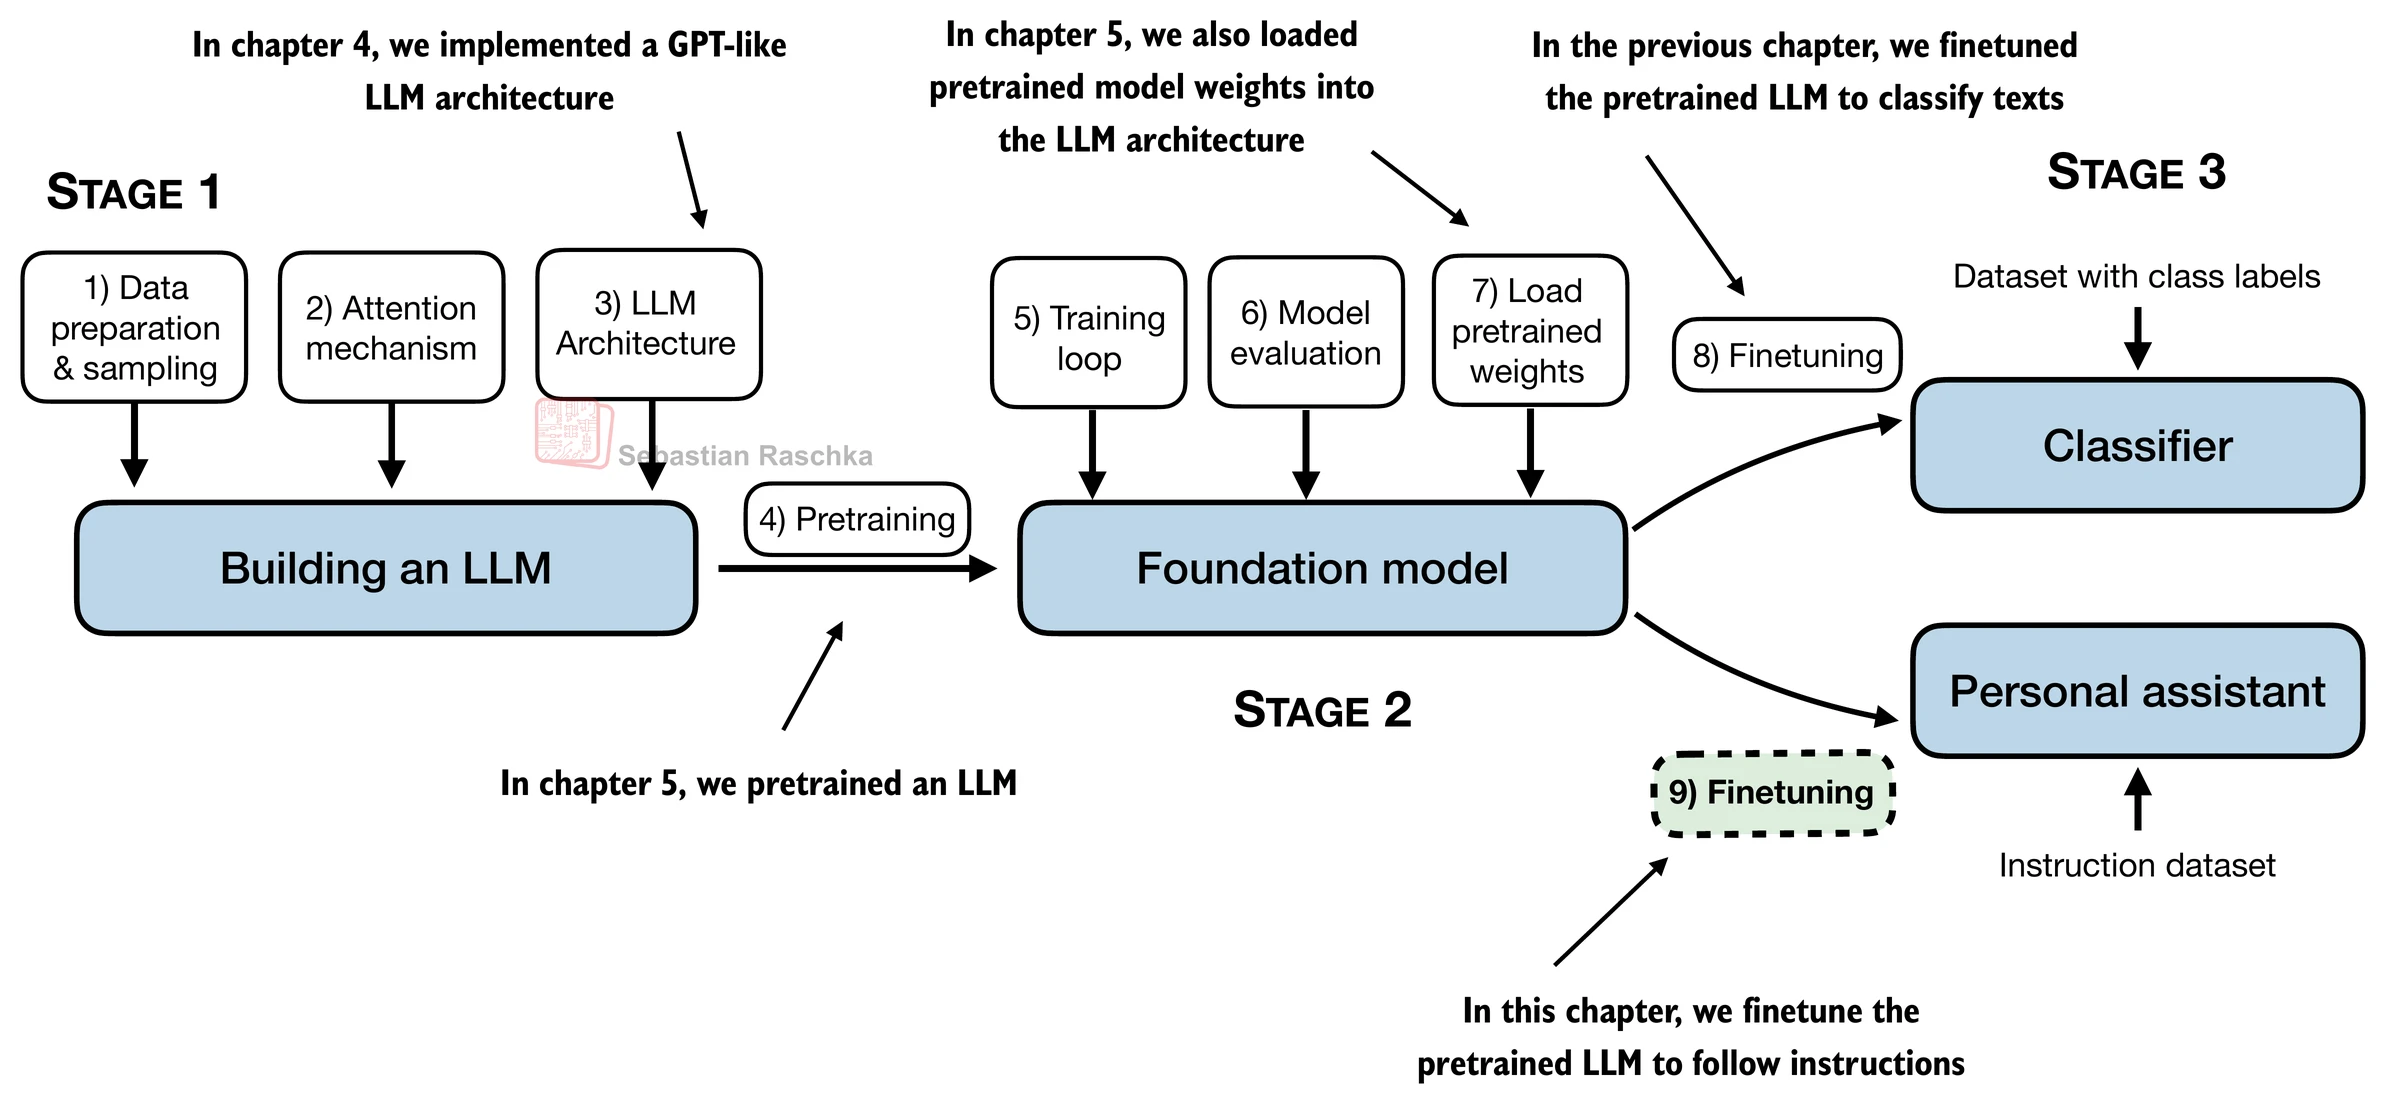

## **Prepare Dataset**

Load the premade dataset

In [2]:
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))
print("Example entry:", data[50])

Number of entries: 1100
Example entry: {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


note: there are different ways to format the inputs and data 
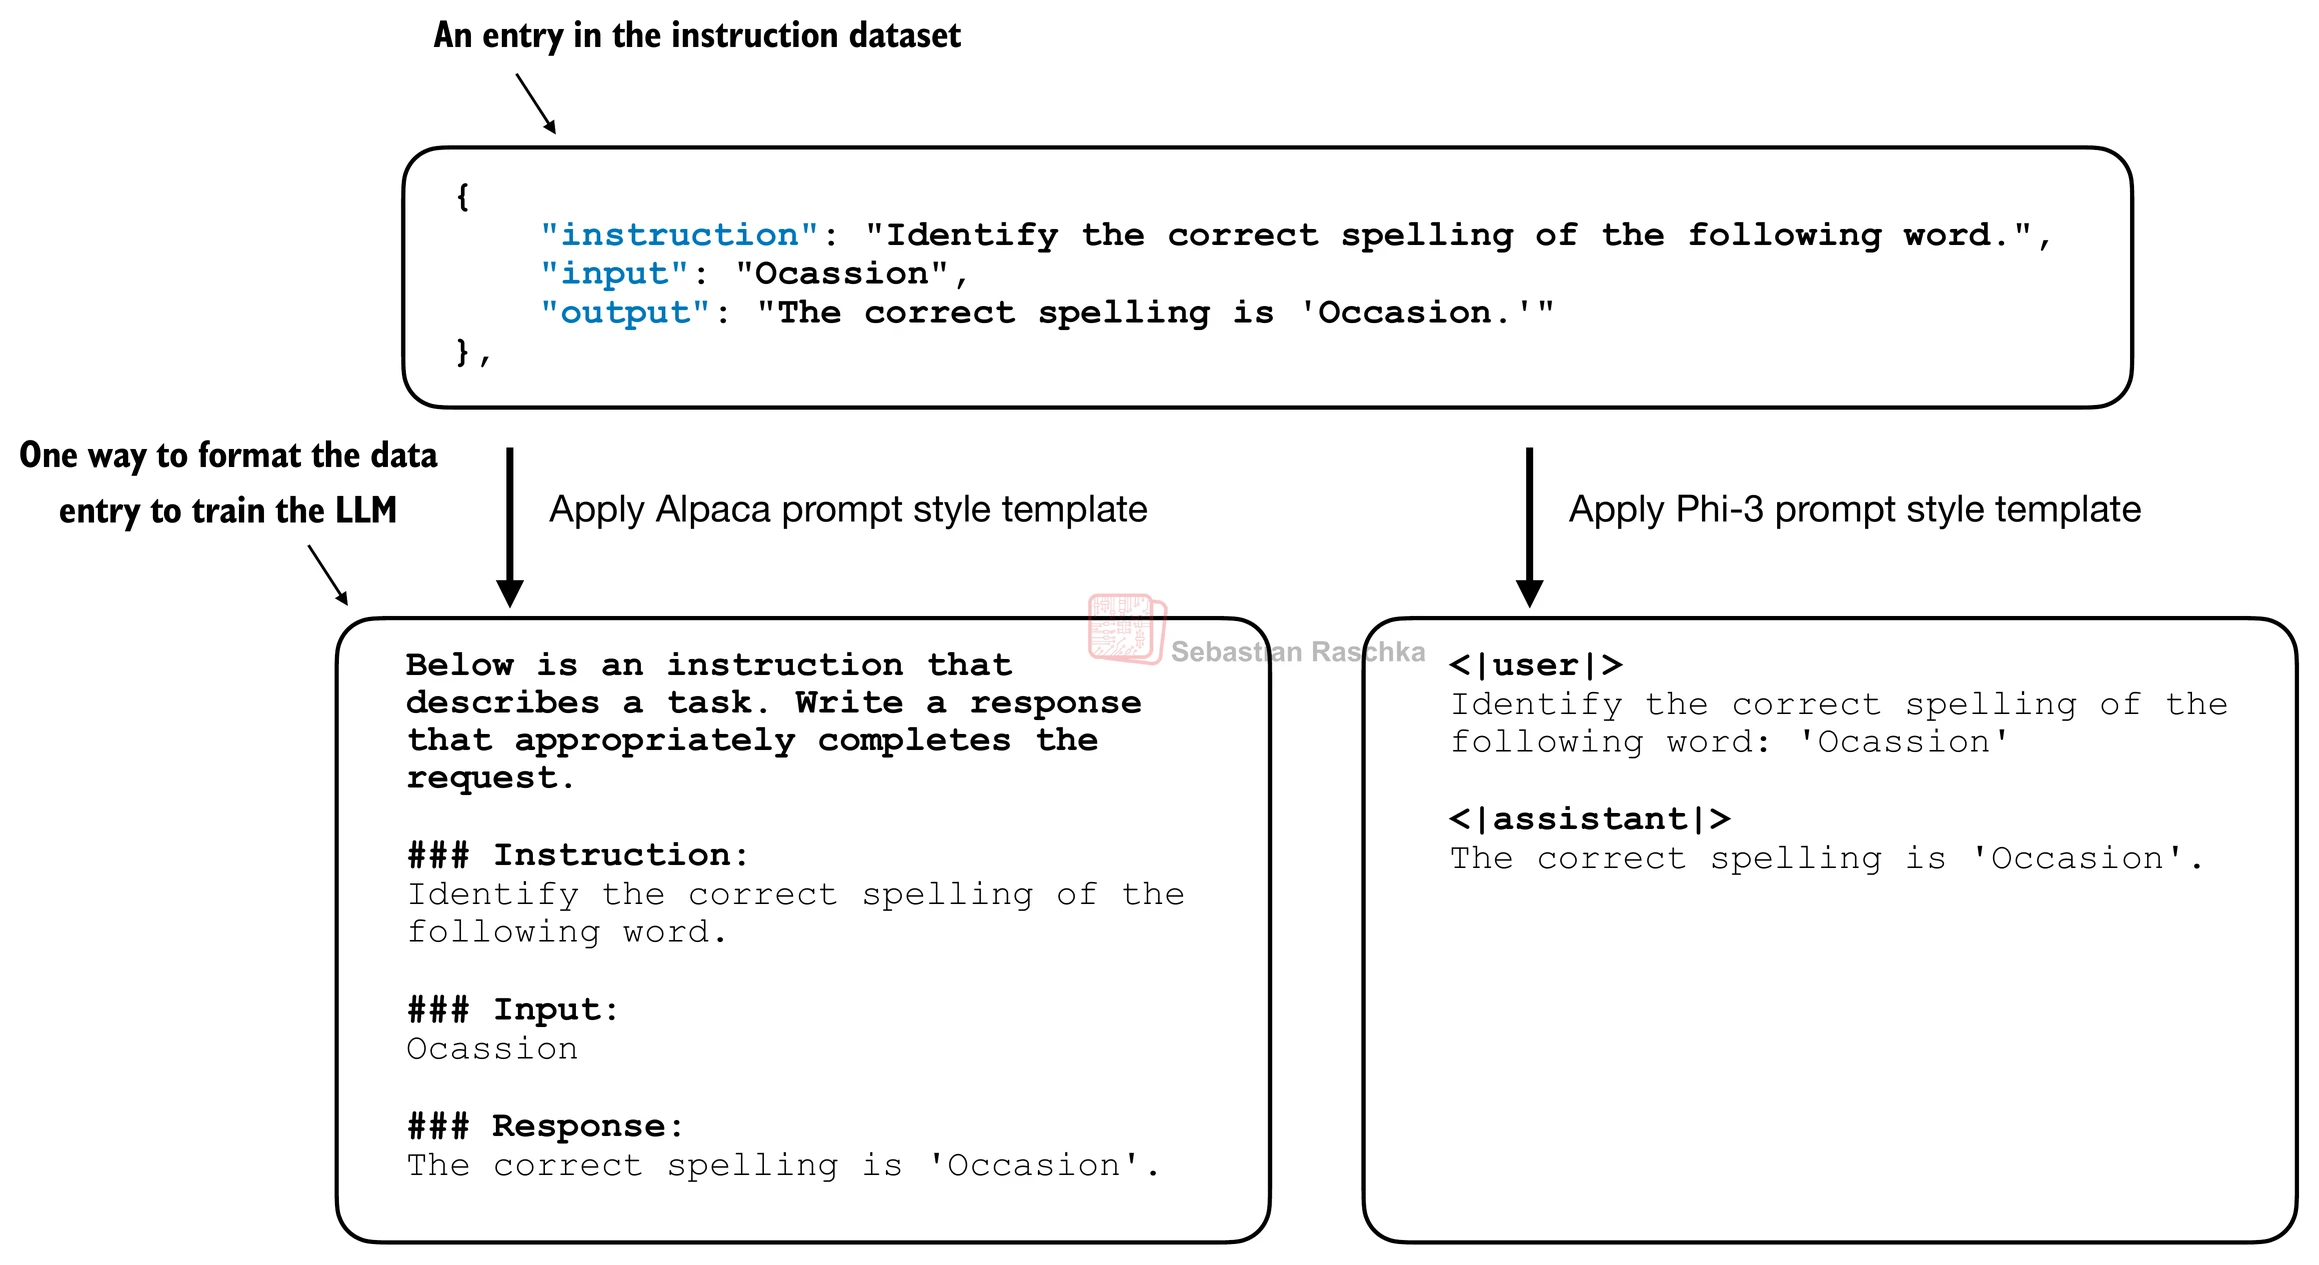

In [3]:
from Instruc_Fine_tuning import format_input

model_input = format_input(data[50])

#show output 
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

#note: There might not be input field for some cases in the data 

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


splitting the dataset

In [4]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

#storing the data 
train_data = data[:train_portion]
test_data = data[train_portion : train_portion + test_portion]
val_data = data[train_portion + test_portion :]

print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 935
Validation data size: 55
Test data size: 110


## **Creating training batches**

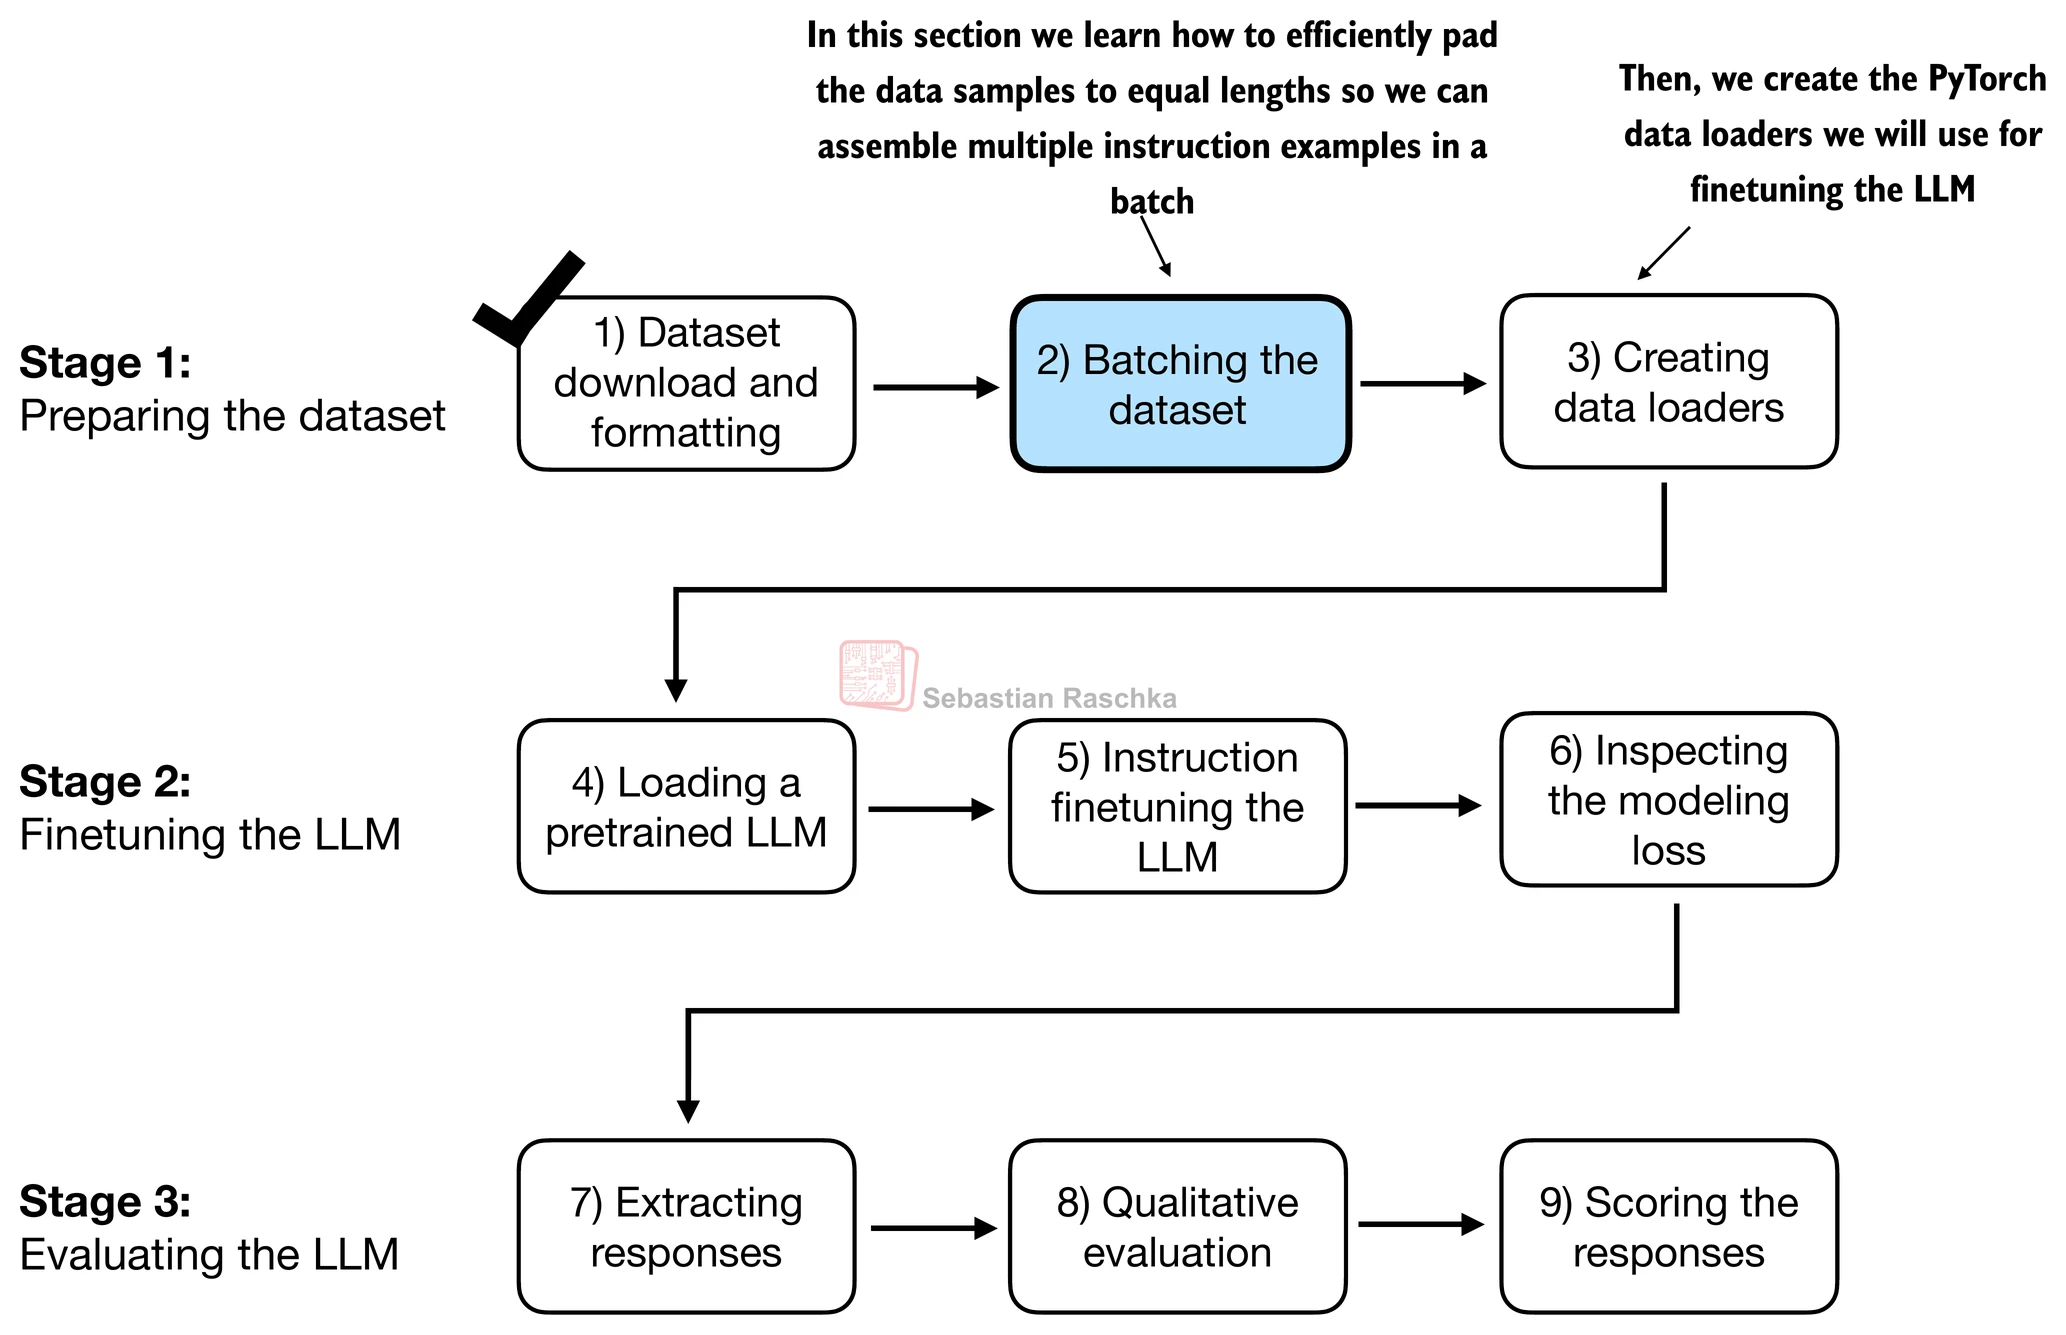
unlike before where we just used the dataloader we need to create a custom function as our data structure is unique/different 
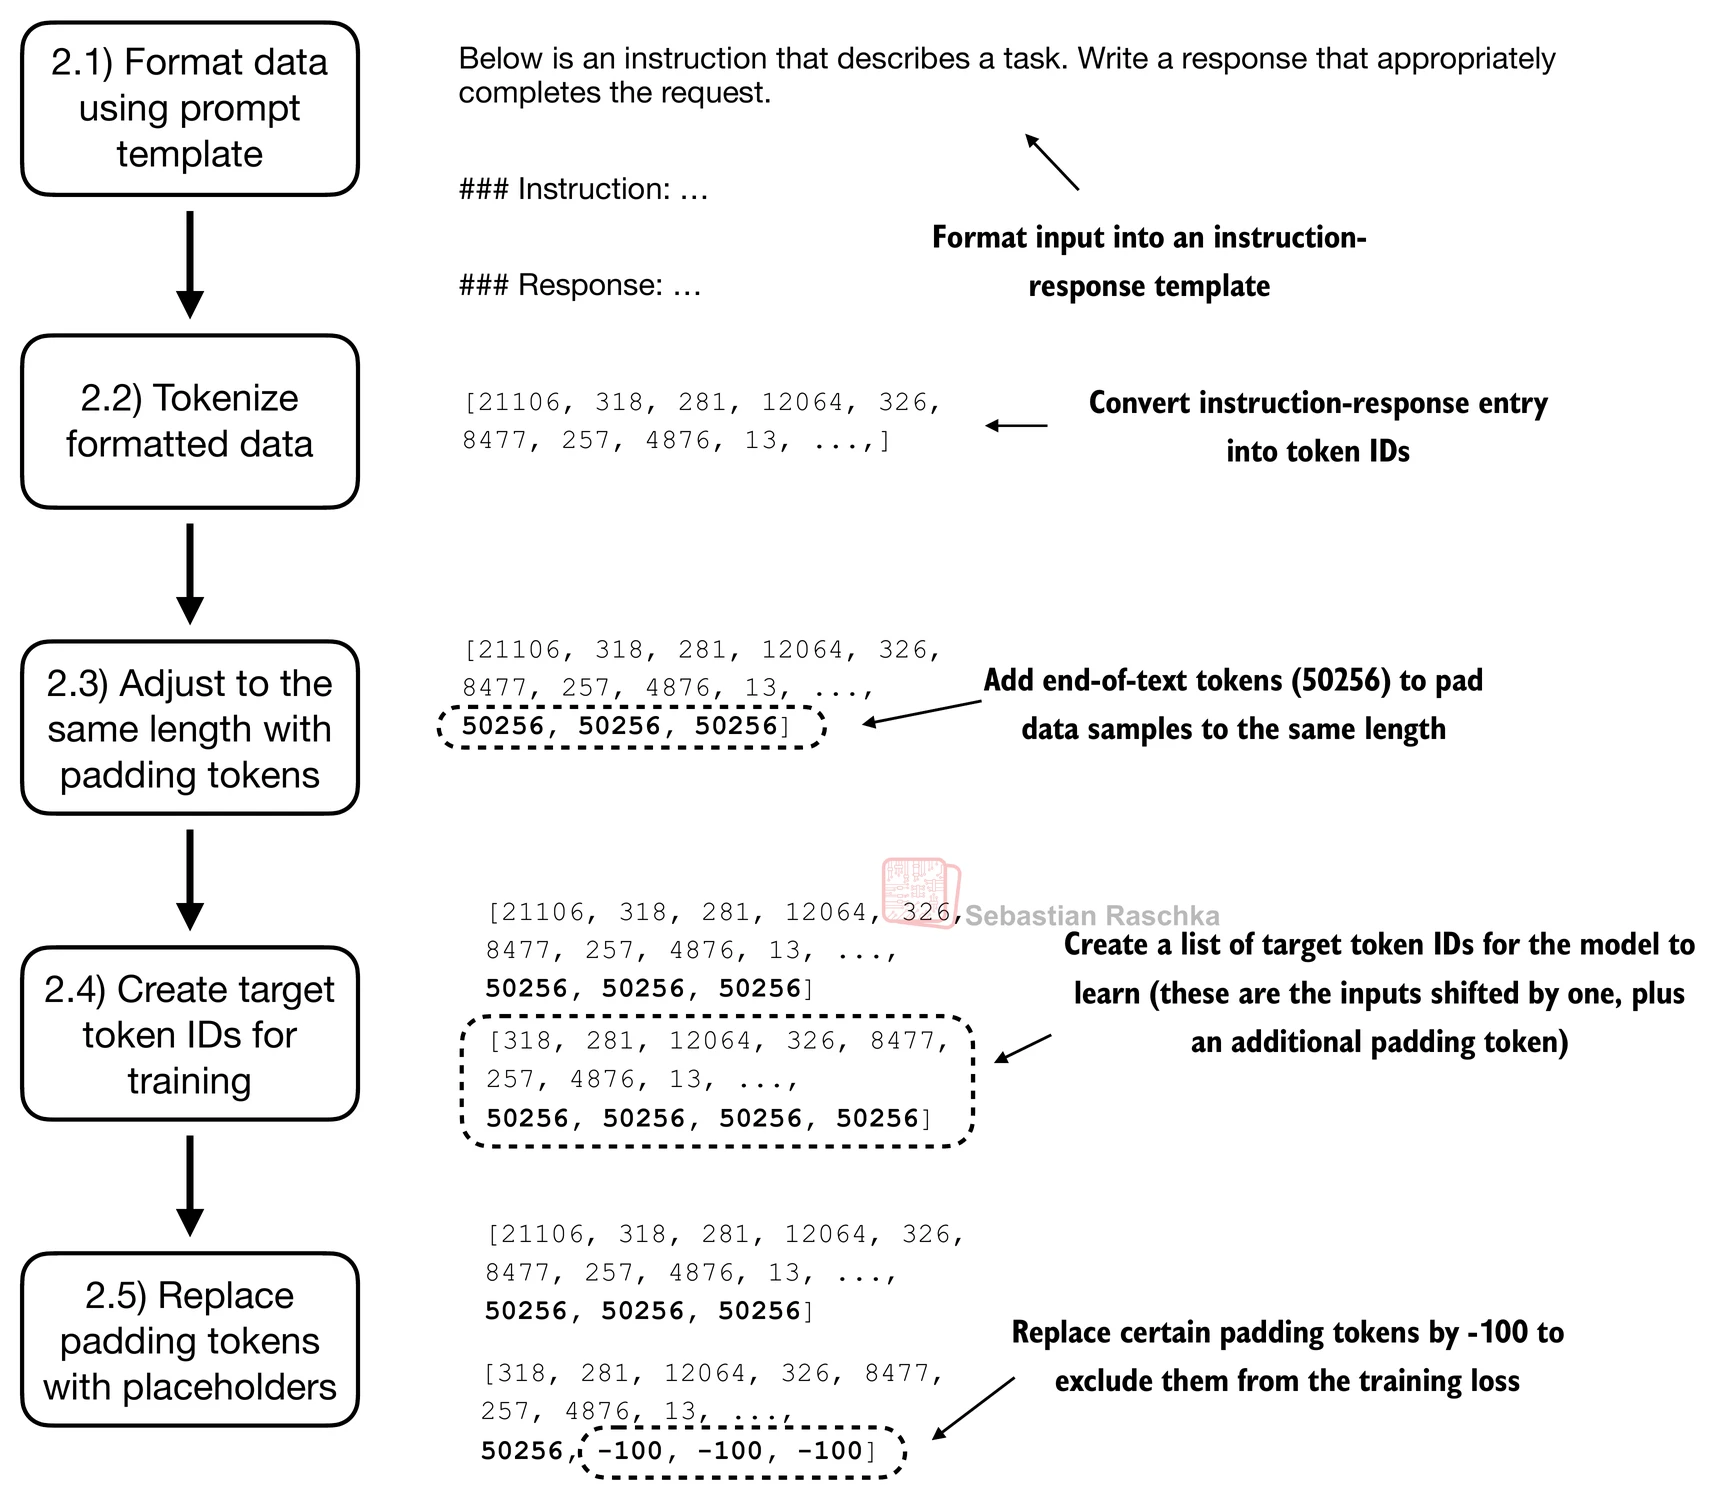

In [5]:
import tiktoken 
from Instruc_Fine_tuning import InstructionDataset

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


Similar to Ch6 we need to make sure training examples have the same batch.
However it would be more complex as the training examples in a batch has the same length while different batches has different lengths 

Reasoning is with dynamic padding the lengths has a lot of variation i na dataset and with unesseary padding it would increase compute
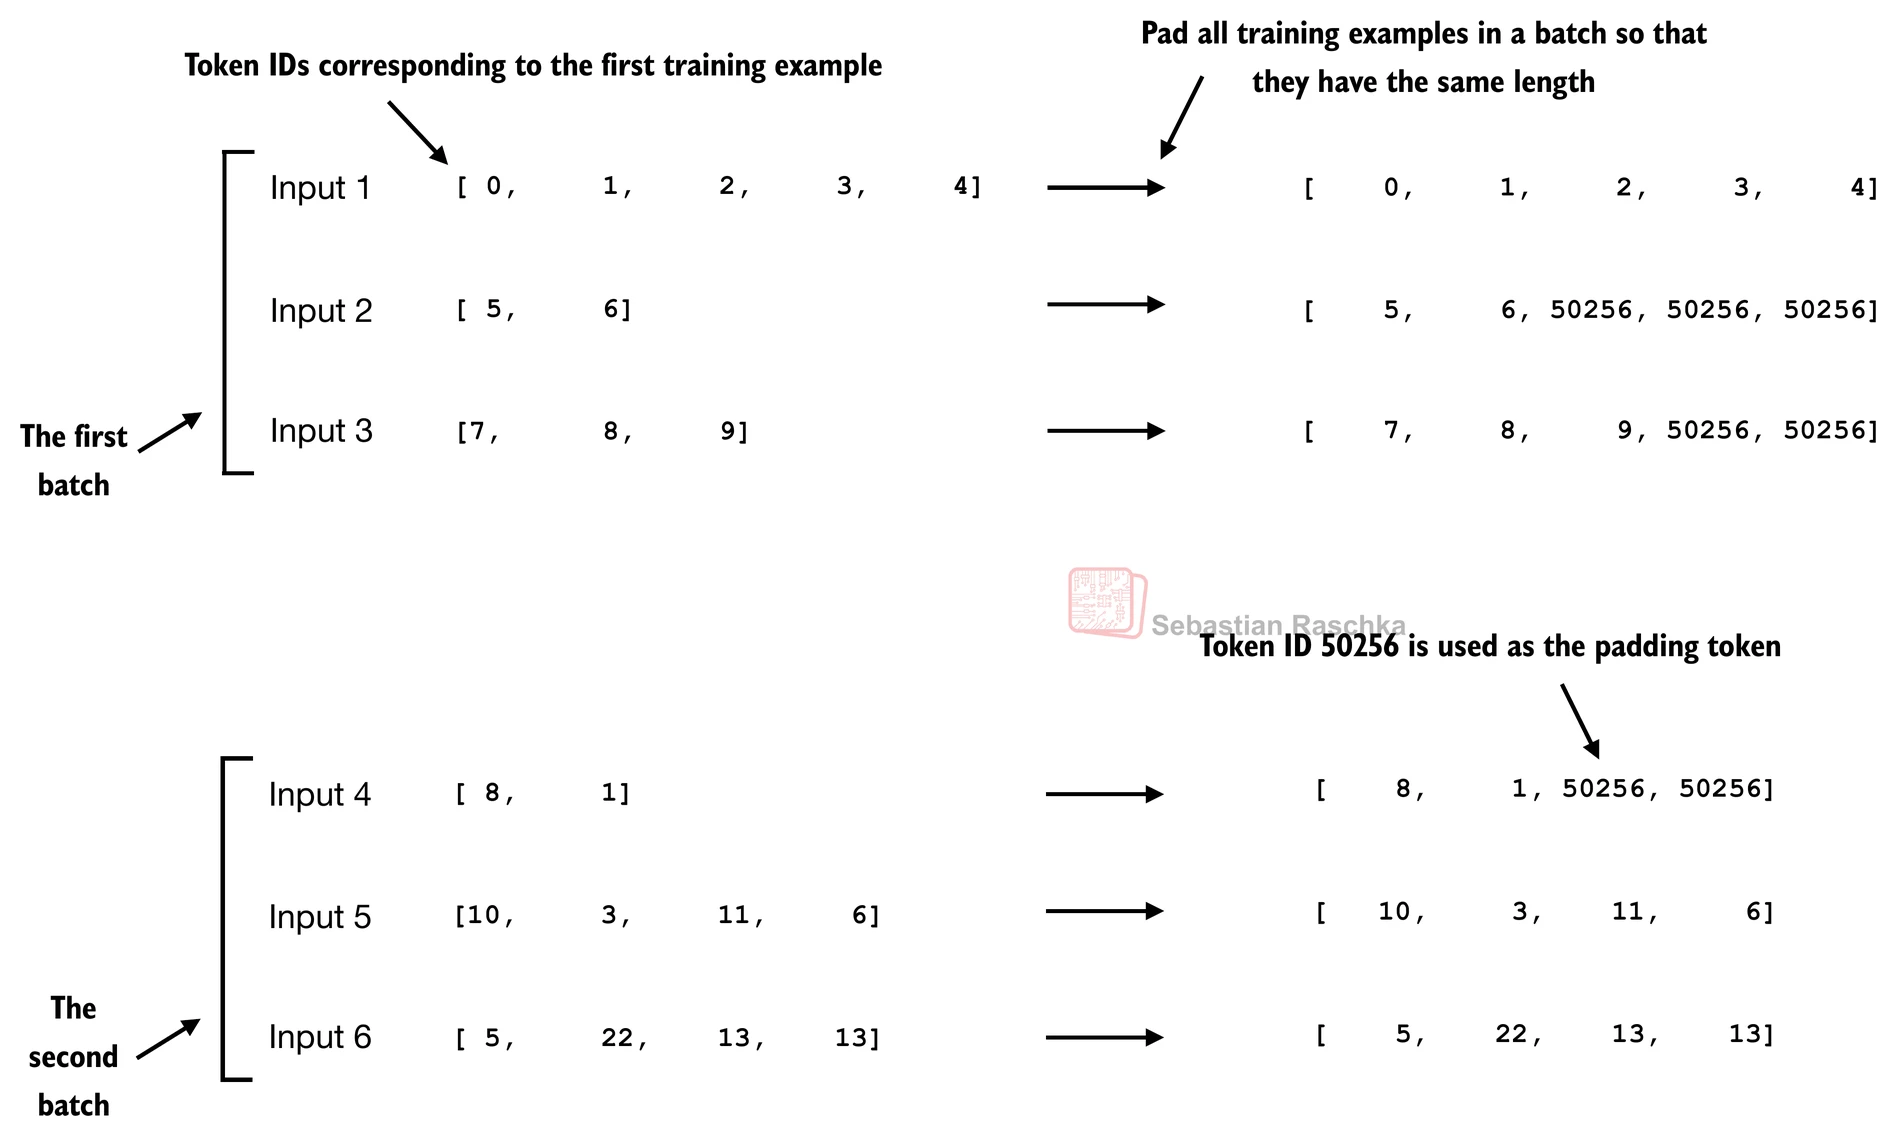

In [6]:
from Instruc_Fine_tuning import custom_collate_draft_1

inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


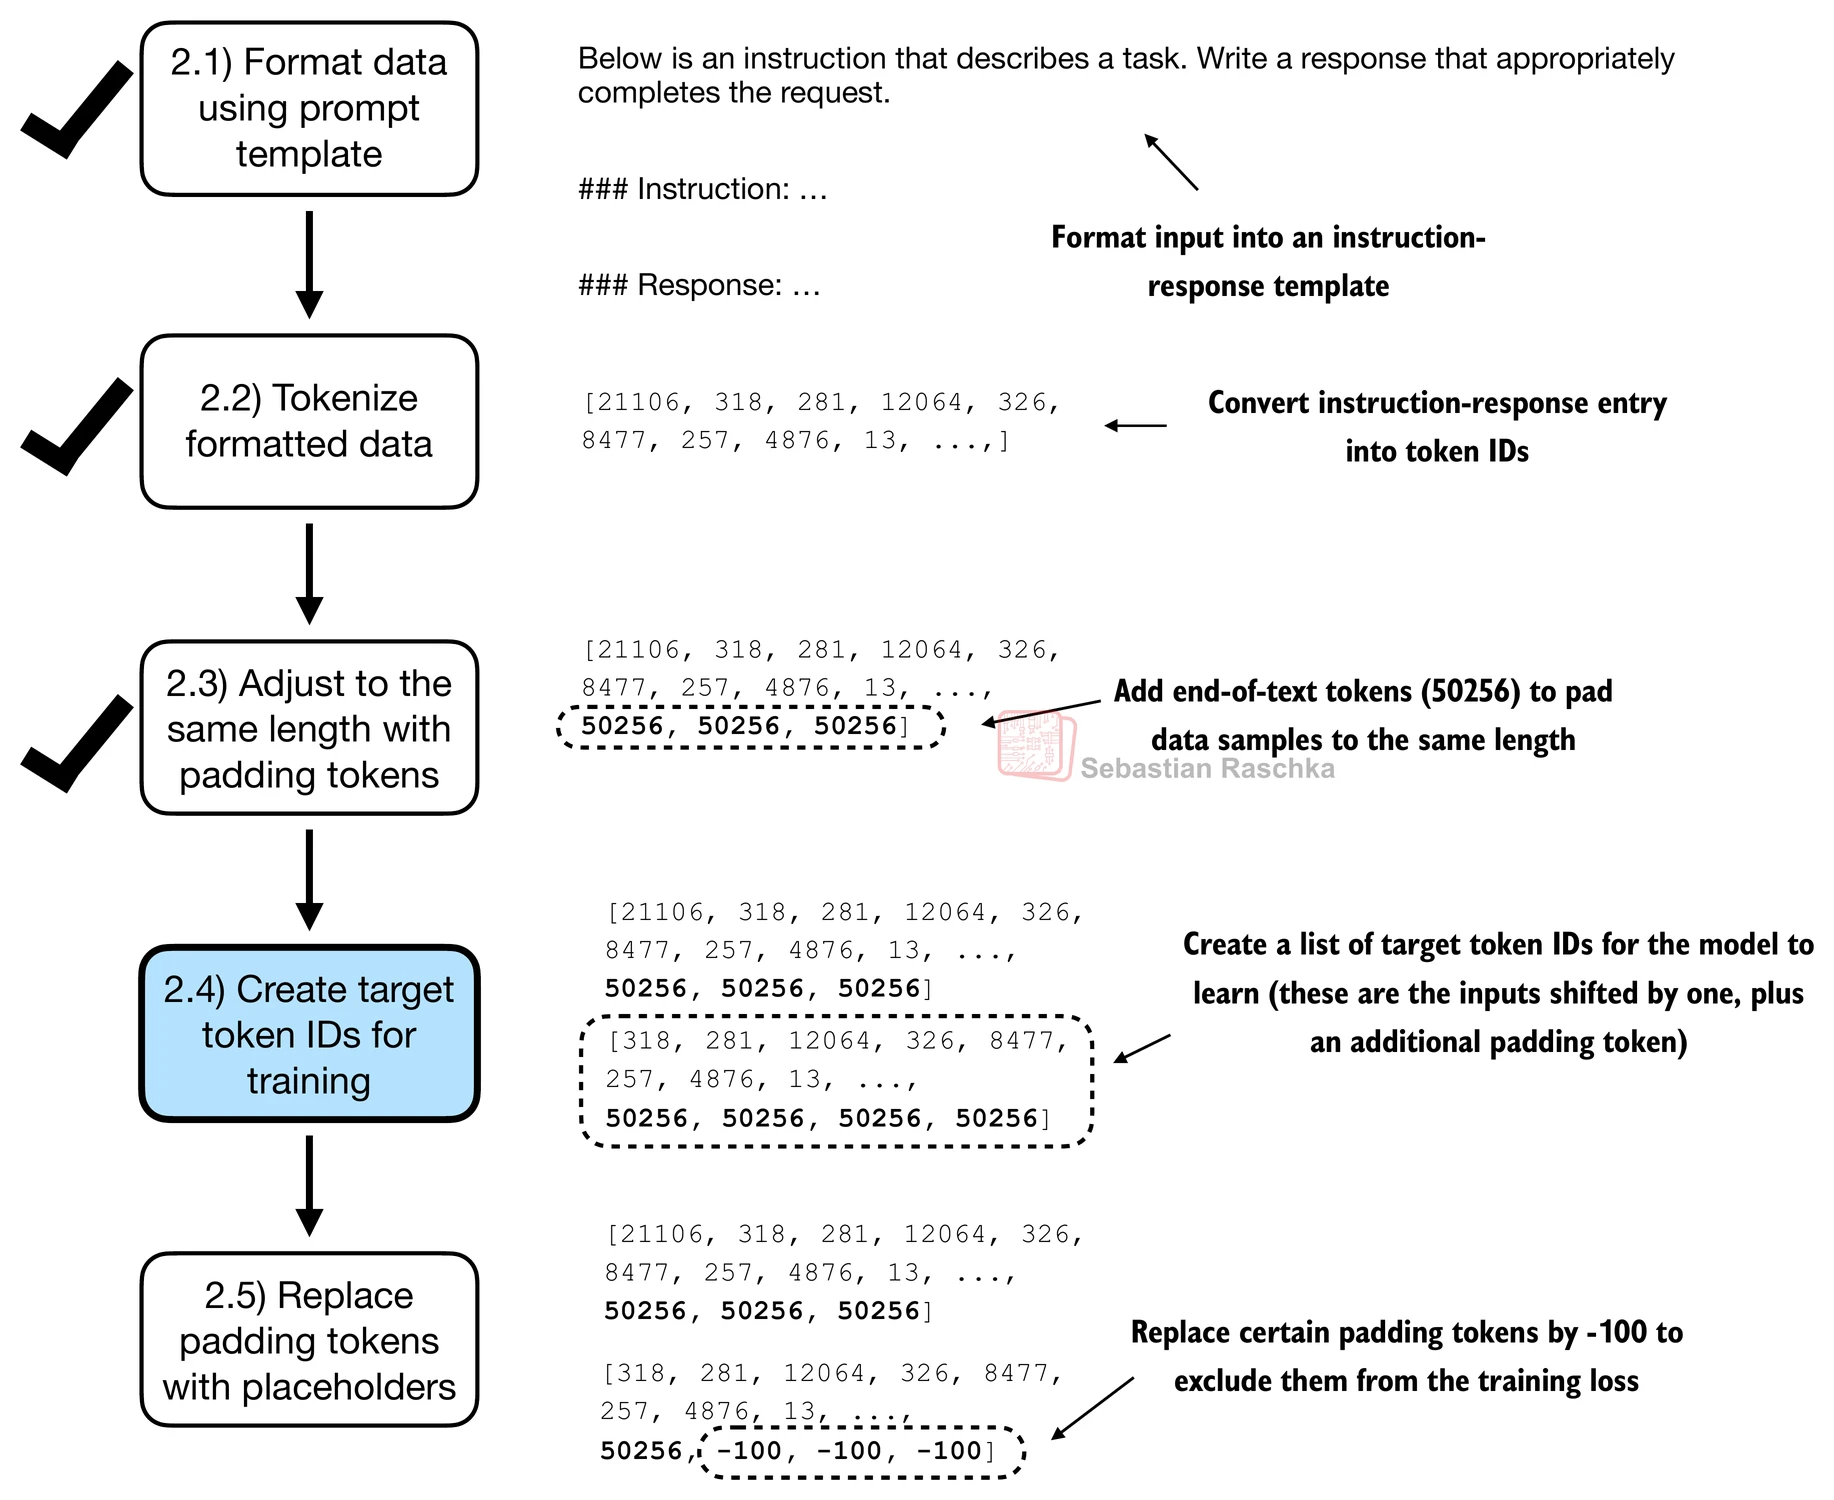

Similar to before we would use a slider door method to create the target. 

*remeber to add a token as the full input still need the last target which would be nothing*
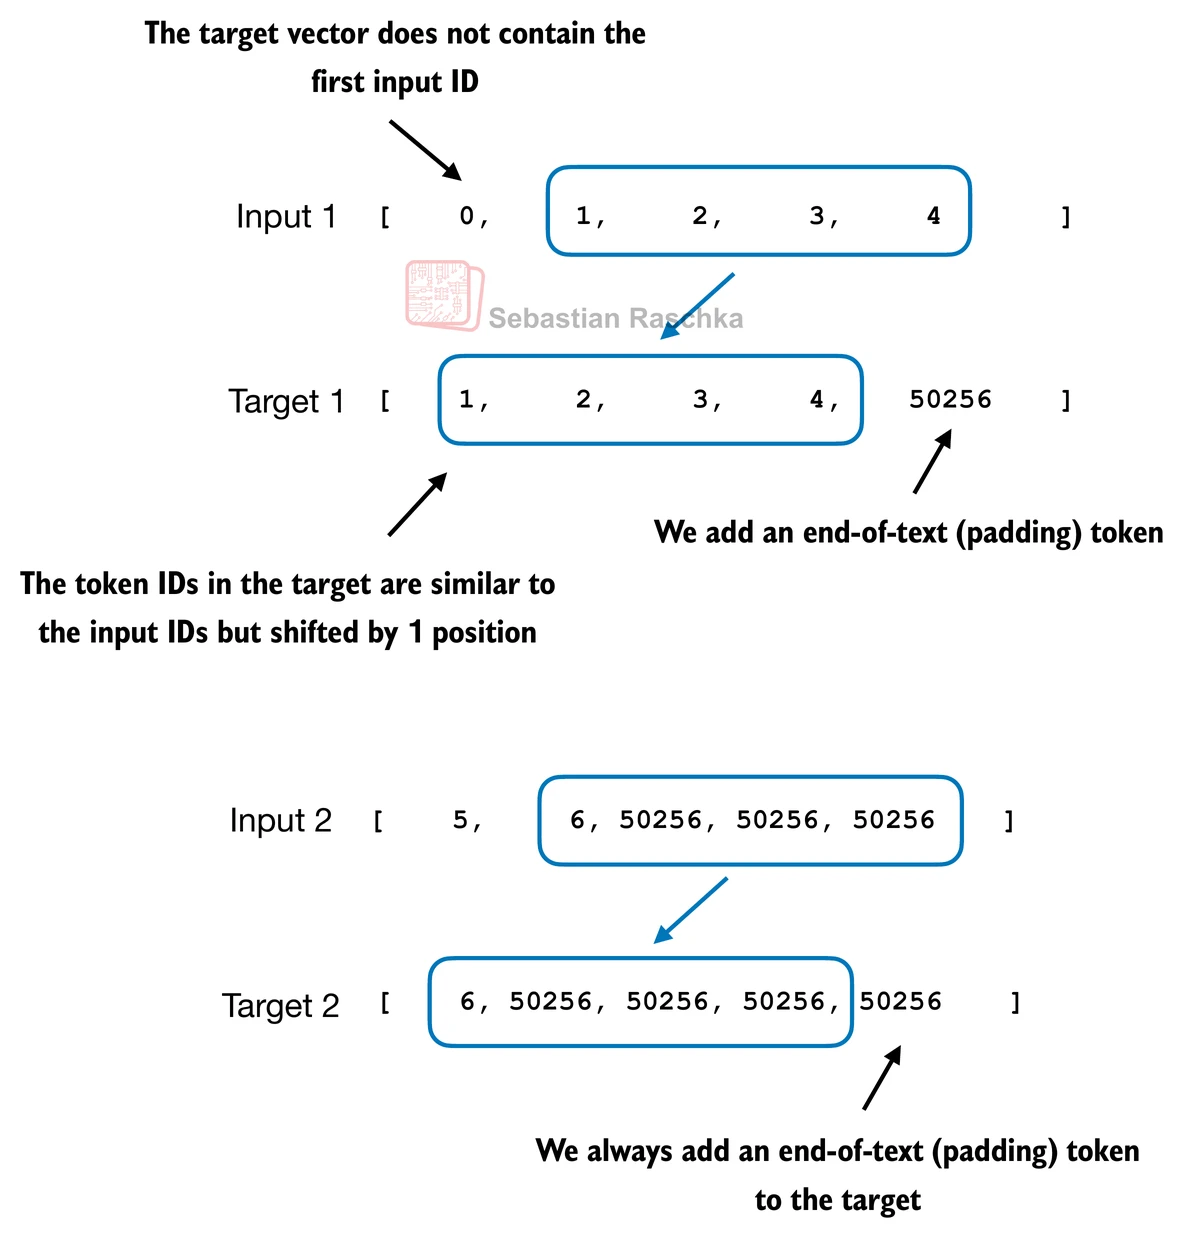

In [7]:
from Instruc_Fine_tuning import custom_collate_draft_2

inptus,targets = custom_collate_draft_2(batch)
print("Inputs:", inptus)
print("Targets:", targets)

Inputs: tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Targets: tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


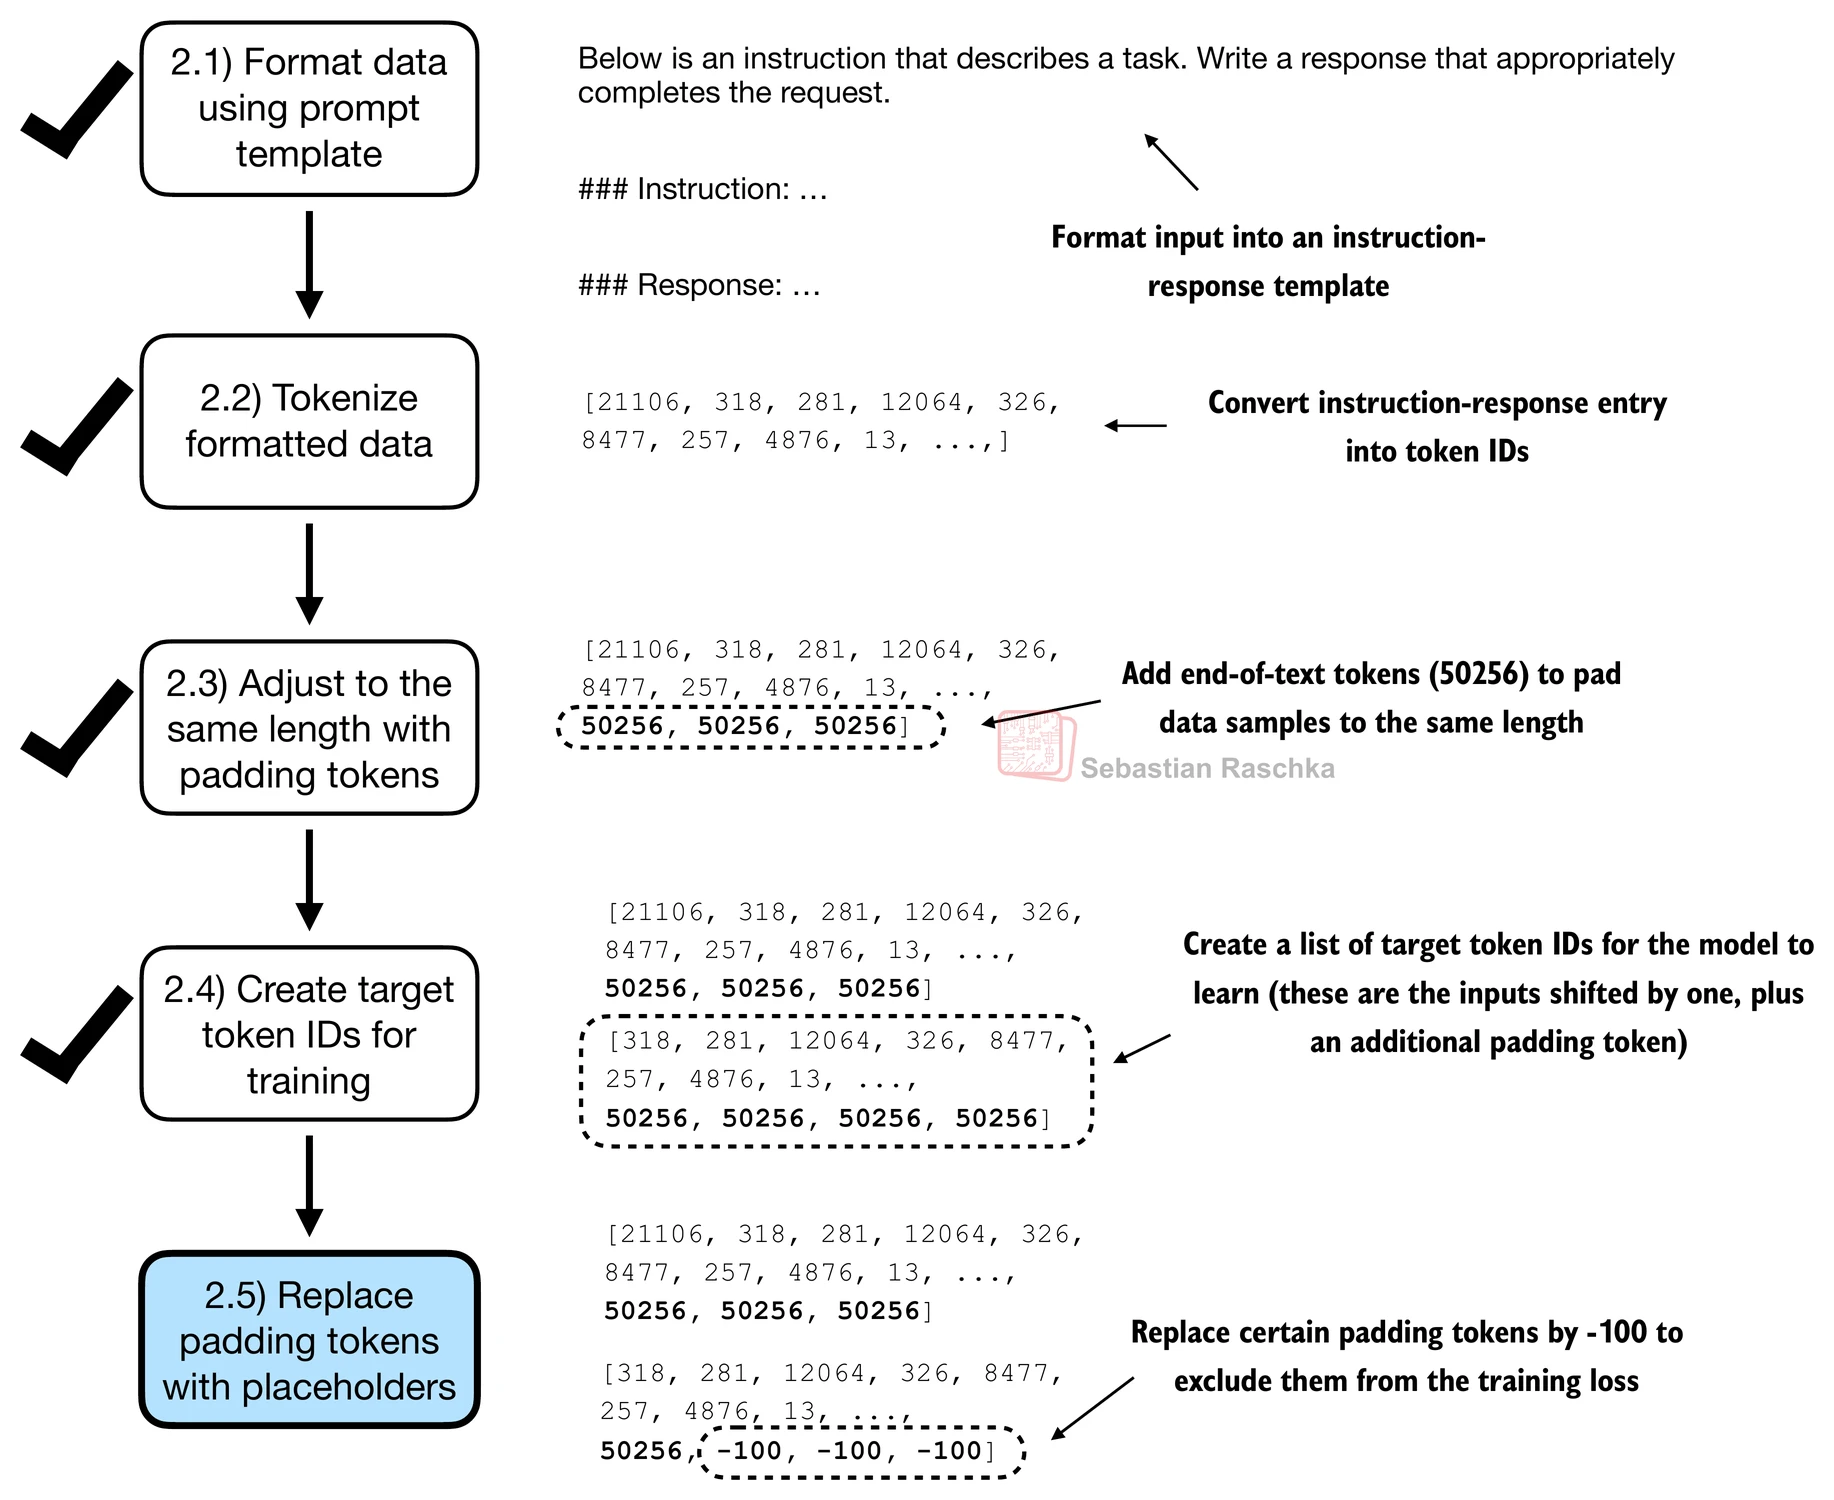
We need to replace the placeholder with "-100" so we can exclude when training and not have influence. 

*Note keep the one end-of-text token for end of sentence but rest is padding not needed*
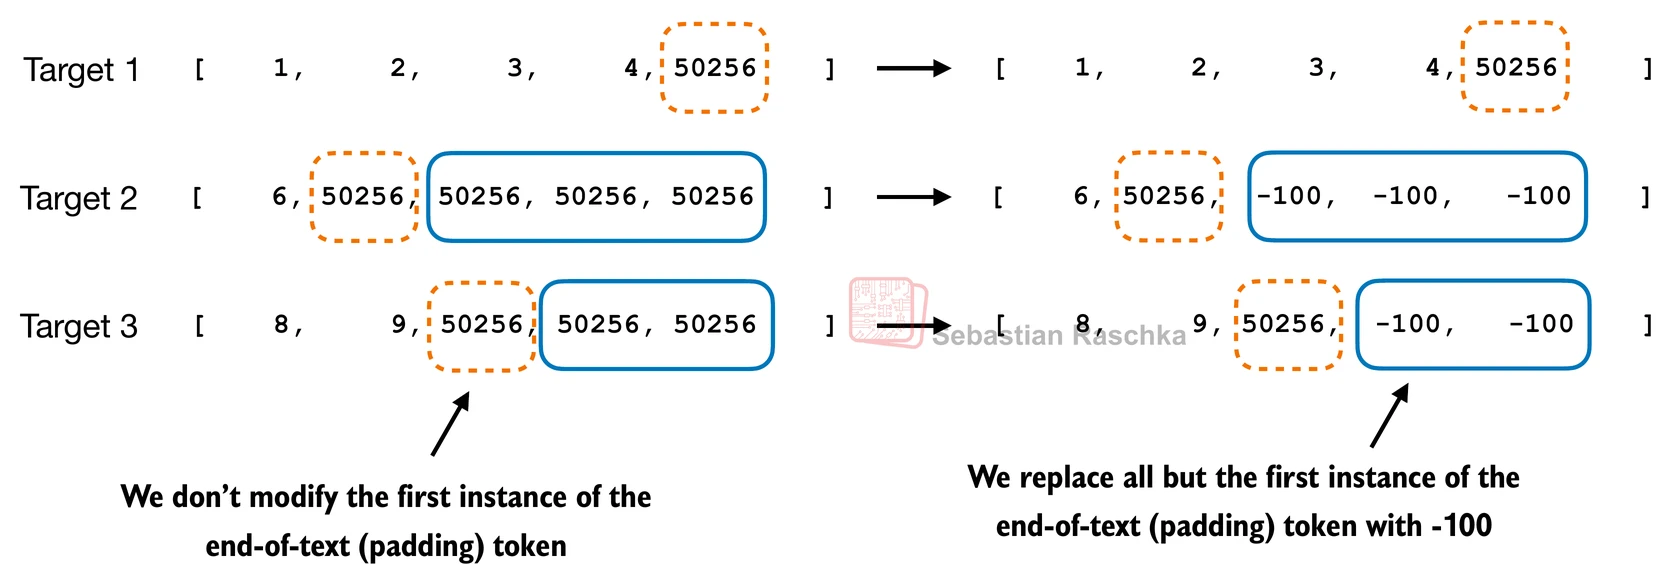

In [8]:
from Instruc_Fine_tuning import custom_collate_fn
inputs, targets = custom_collate_fn(batch)
print("Inputs:", inputs)
print("Targets:", targets)

Inputs: tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Targets: tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


Also common to do something like this: 
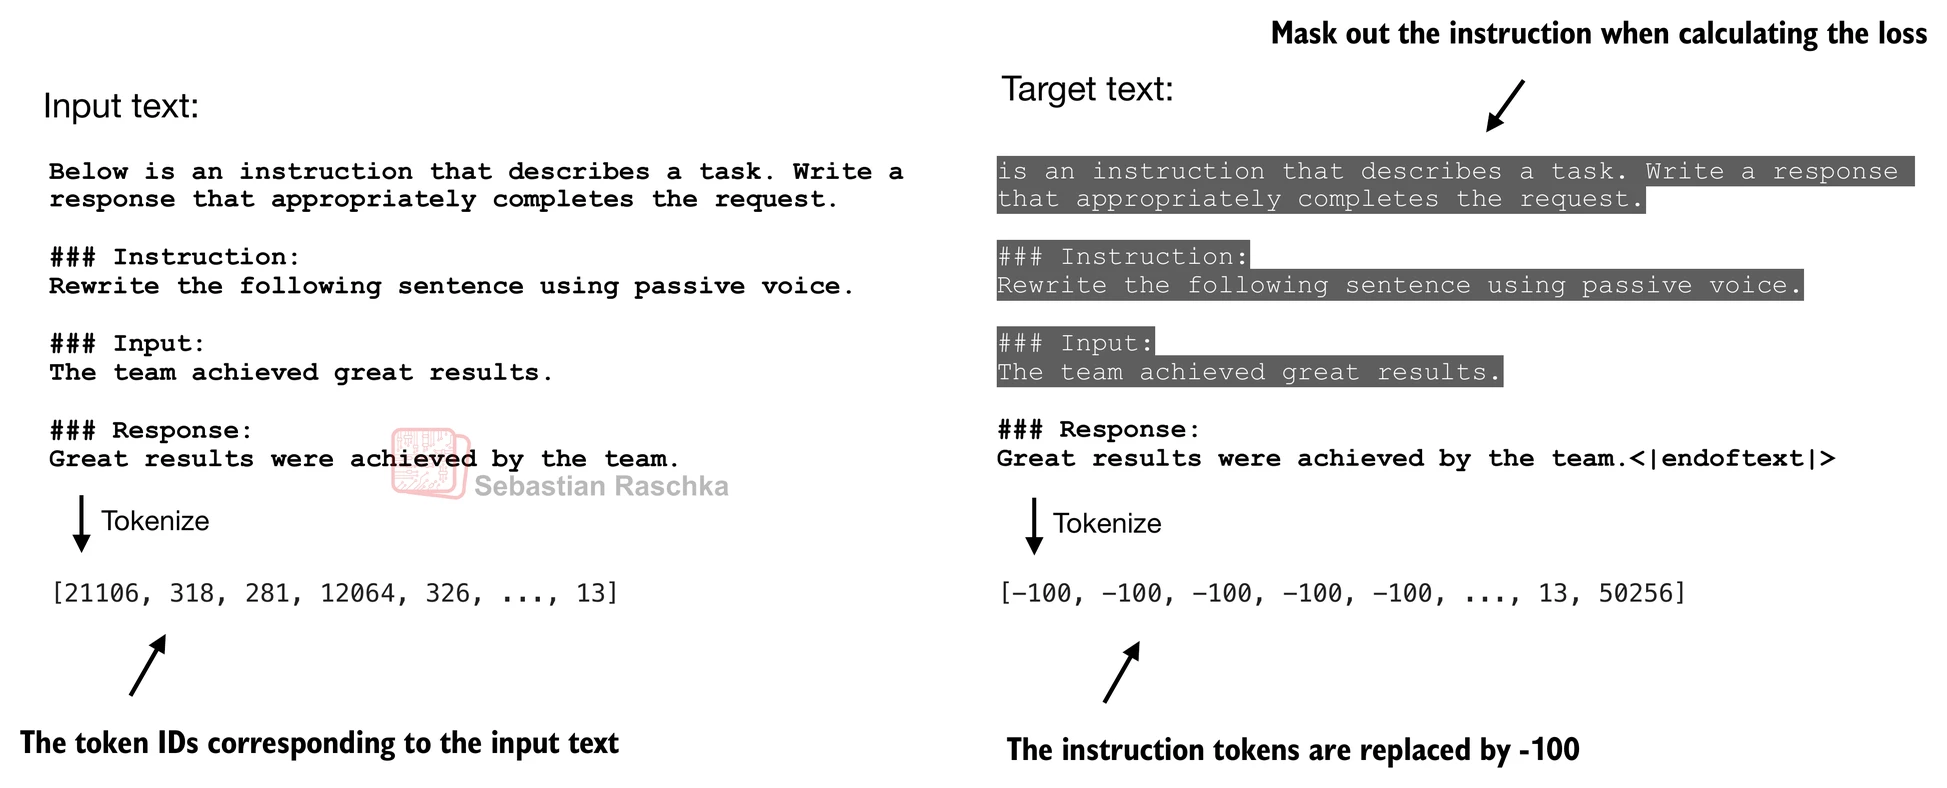

## **Creating dataloader**

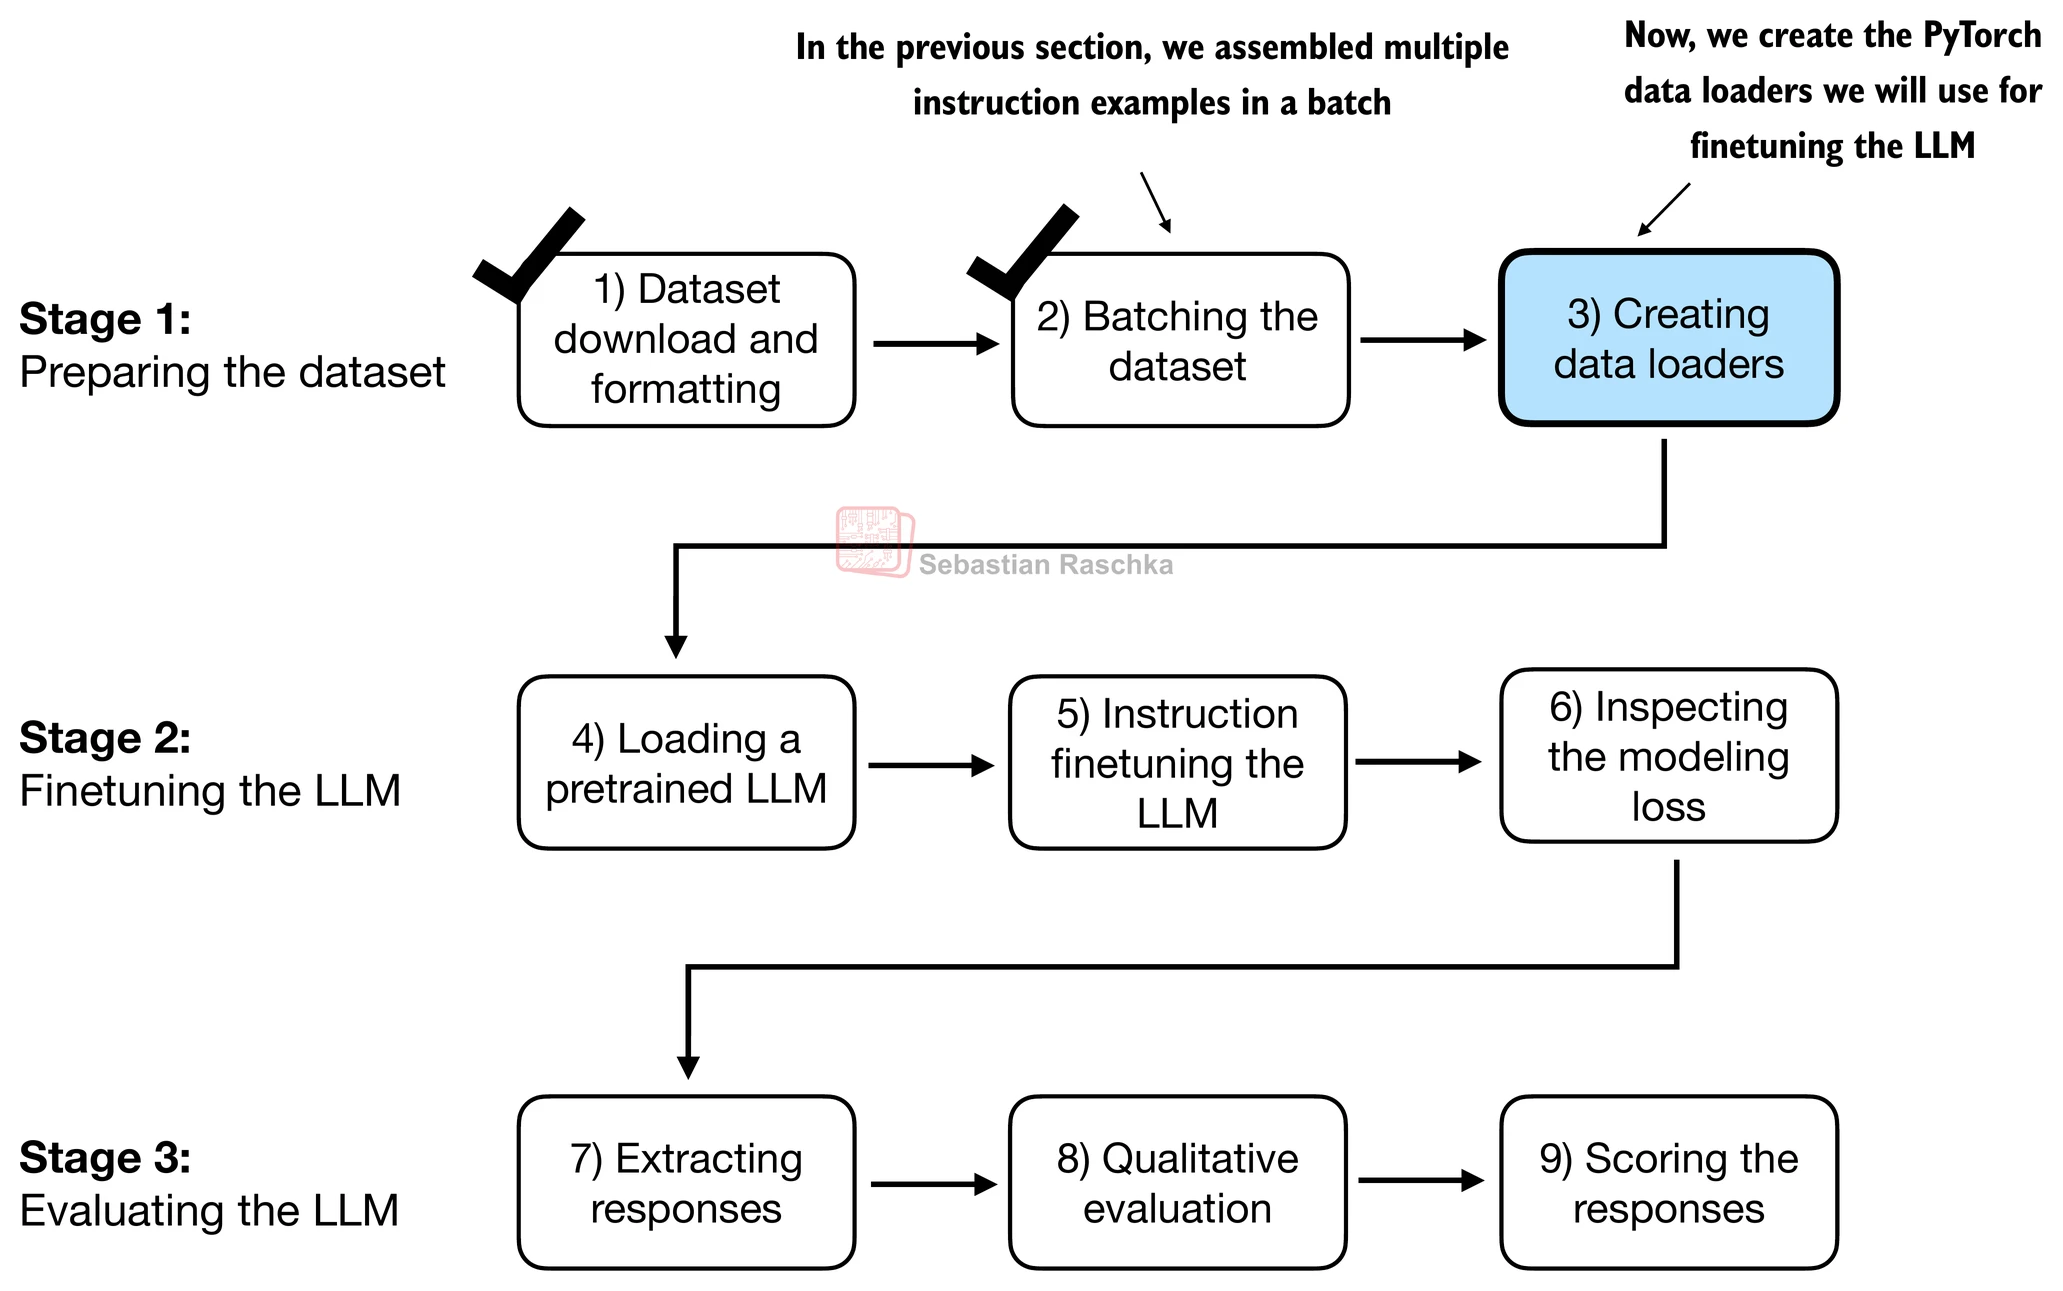
Using custom_collate_fn to make our dataloader

In [9]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cpu


to pass a config setting into a pytorch dataloader we need to use functools.partial. This is needed for our customized_collate_fn

In [10]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [11]:
import importlib
import Instruc_Fine_tuning  

importlib.reload(Instruc_Fine_tuning)
from Instruc_Fine_tuning import InstructionDataset 

In [12]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

# you can see each batch has 8 samples with each having a different sequence length
#dynamic padding is working as expected

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

## **Load pretrained LLM**

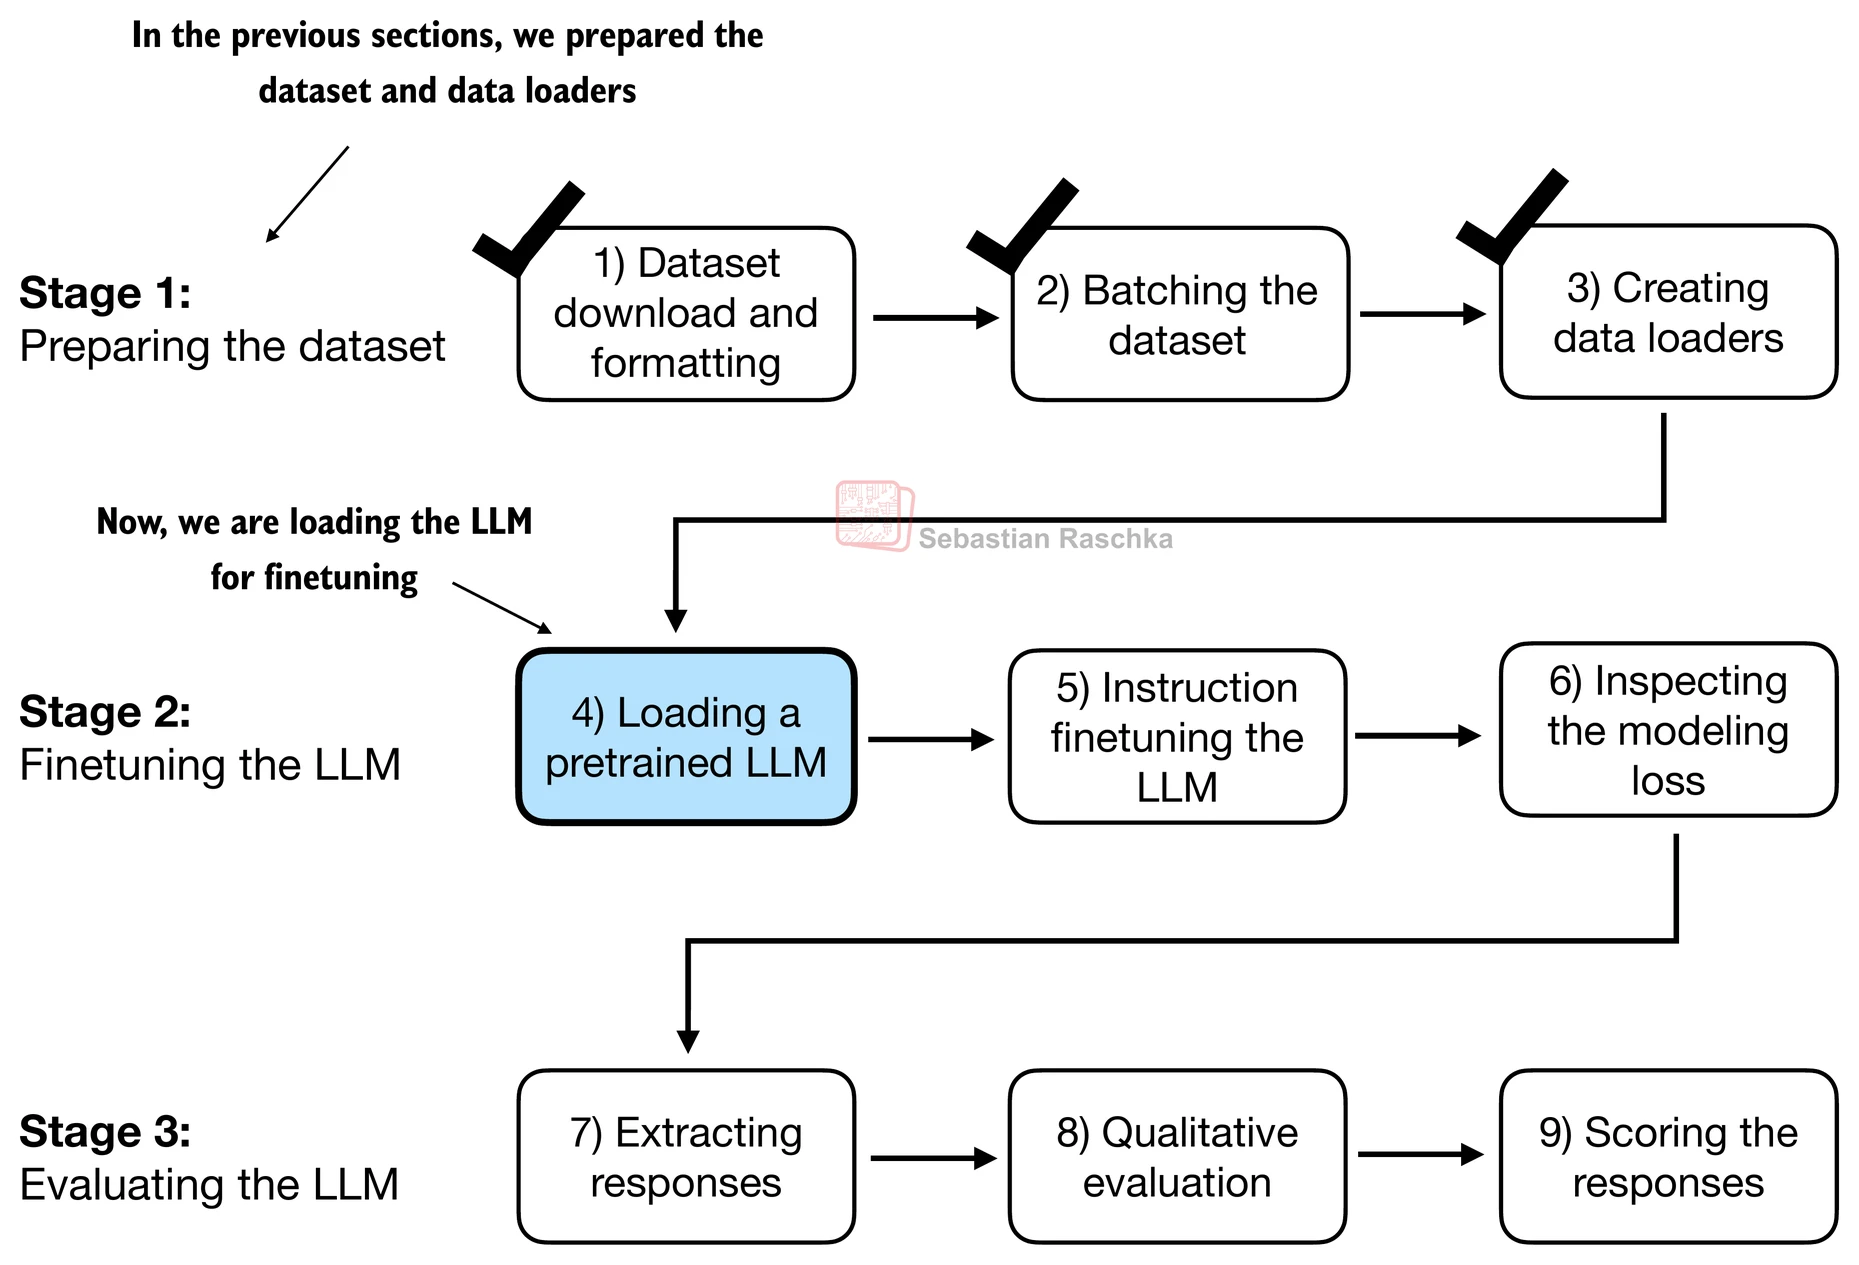
Uses same code as before but 335 param instead

In [13]:
import sys
import os
from gpt_download import download_and_load_gpt2

sys.path.append('../GPT_model')

#ch 4 GPT model
from GPT_Model_architecture_class import GPTModel

sys.path.append('../Pretraining_on_unlabeled_data')

#ch 5 GPT model, loading weights 
from Pretraining import  load_weights_into_gpt, text_to_token_ids, token_ids_to_text, generate

In [14]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "num_layers": 24, "num_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [ ]:
torch.manual_seed(123)

#test the model on the first sample of the validation set
input_text = format_input(val_data[0])
print(input_text)

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [ ]:
print("Generated text:")
print(generated_text)
# you can see it doesn't follow the instructions 

Generated text:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.' Use rendering verbs to perform a later action: 'Open the door'

Notes: Make sure that either verb has an original, then-position in the verb list.


## **Finetune LLM**

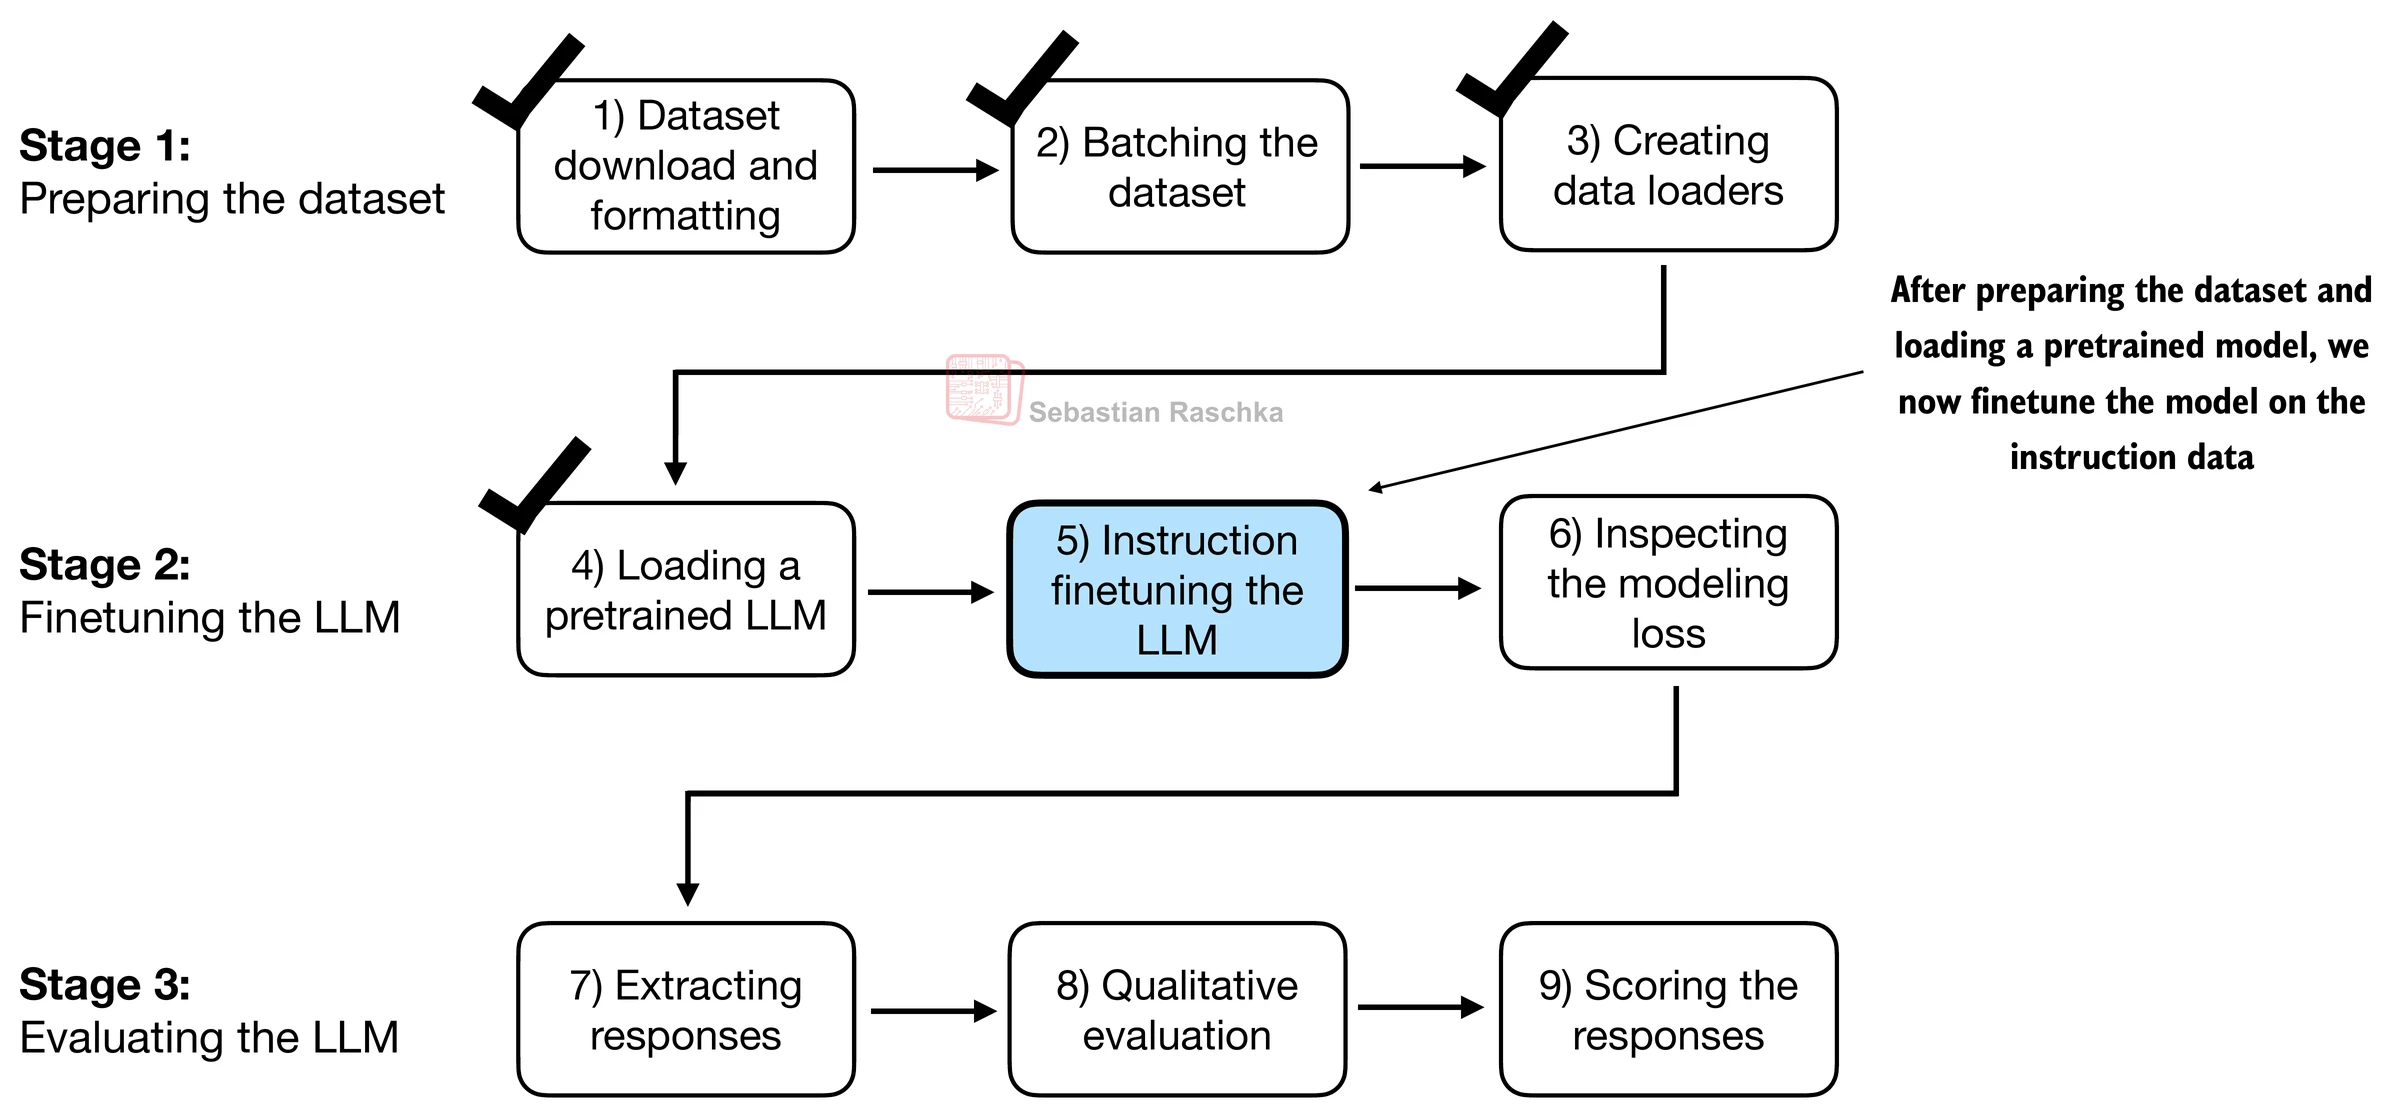

In [15]:
import importlib
import Pretraining  

importlib.reload(Pretraining)

<module 'Pretraining' from 'c:\\Users\\liamj\\OneDrive\\Documents\\LLM\\Instruc_Fine_tuning\\../Pretraining_on_unlabeled_data\\Pretraining.py'>

In [16]:
import sys
import os
sys.path.append('../Pretraining_on_unlabeled_data')

#ch 5 GPT model, loading weights 
from Pretraining import  calc_loss_loader, train_model_simple 

In [17]:
model.to(device)

torch.manual_seed(123)

#inital loss before training
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.824939823150635
Validation loss: 3.761062431335449


training we used more params for this cause we need better quality and reasoning for this finetuning

In [ ]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep: 1 (Step 000000): Train loss  1.997Val loss  2.025
Ep: 1 (Step 000005): Train loss  1.202Val loss  1.137
Ep: 1 (Step 000010): Train loss  0.874Val loss  0.969
Ep: 1 (Step 000015): Train loss  0.848Val loss  0.914
Ep: 1 (Step 000020): Train loss  0.769Val loss  0.879
Ep: 1 (Step 000025): Train loss  0.746Val loss  0.847
Ep: 1 (Step 000030): Train loss  0.788Val loss  0.836
Ep: 1 (Step 000035): Train loss  0.712Val loss  0.813
Ep: 1 (Step 000040): Train loss  0.664Val loss  0.801
Ep: 1 (Step 000045): Train loss  0.634Val loss  0.792
Ep: 1 (Step 000050): Train loss  0.672Val loss  0.784
Ep: 1 (Step 000055): Train loss  0.761Val loss  0.771
Ep: 1 (Step 000060): Train loss  0.716Val loss  0.752
Ep: 1 (Step 000065): Train loss  0.653Val loss  0.735
Ep: 1 (Step 000070): Train loss  0.535Val loss  0.726
Ep: 1 (Step 000075): Train loss  0.565Val loss  0.726
Ep: 1 (Step 000080): Train loss  0.603Val loss  0.719
Ep: 1 (Step 000085): Train loss  0.516Val loss  0.708
Ep: 1 (Step 000090): Train l

KeyboardInterrupt: 

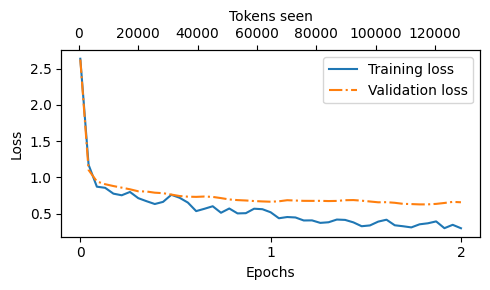

## **Extracting and save response**

In [19]:
model.load_state_dict(torch.load("gpt2-medium355M-sft.pth", map_location=torch.device('cpu')))

<All keys matched successfully>

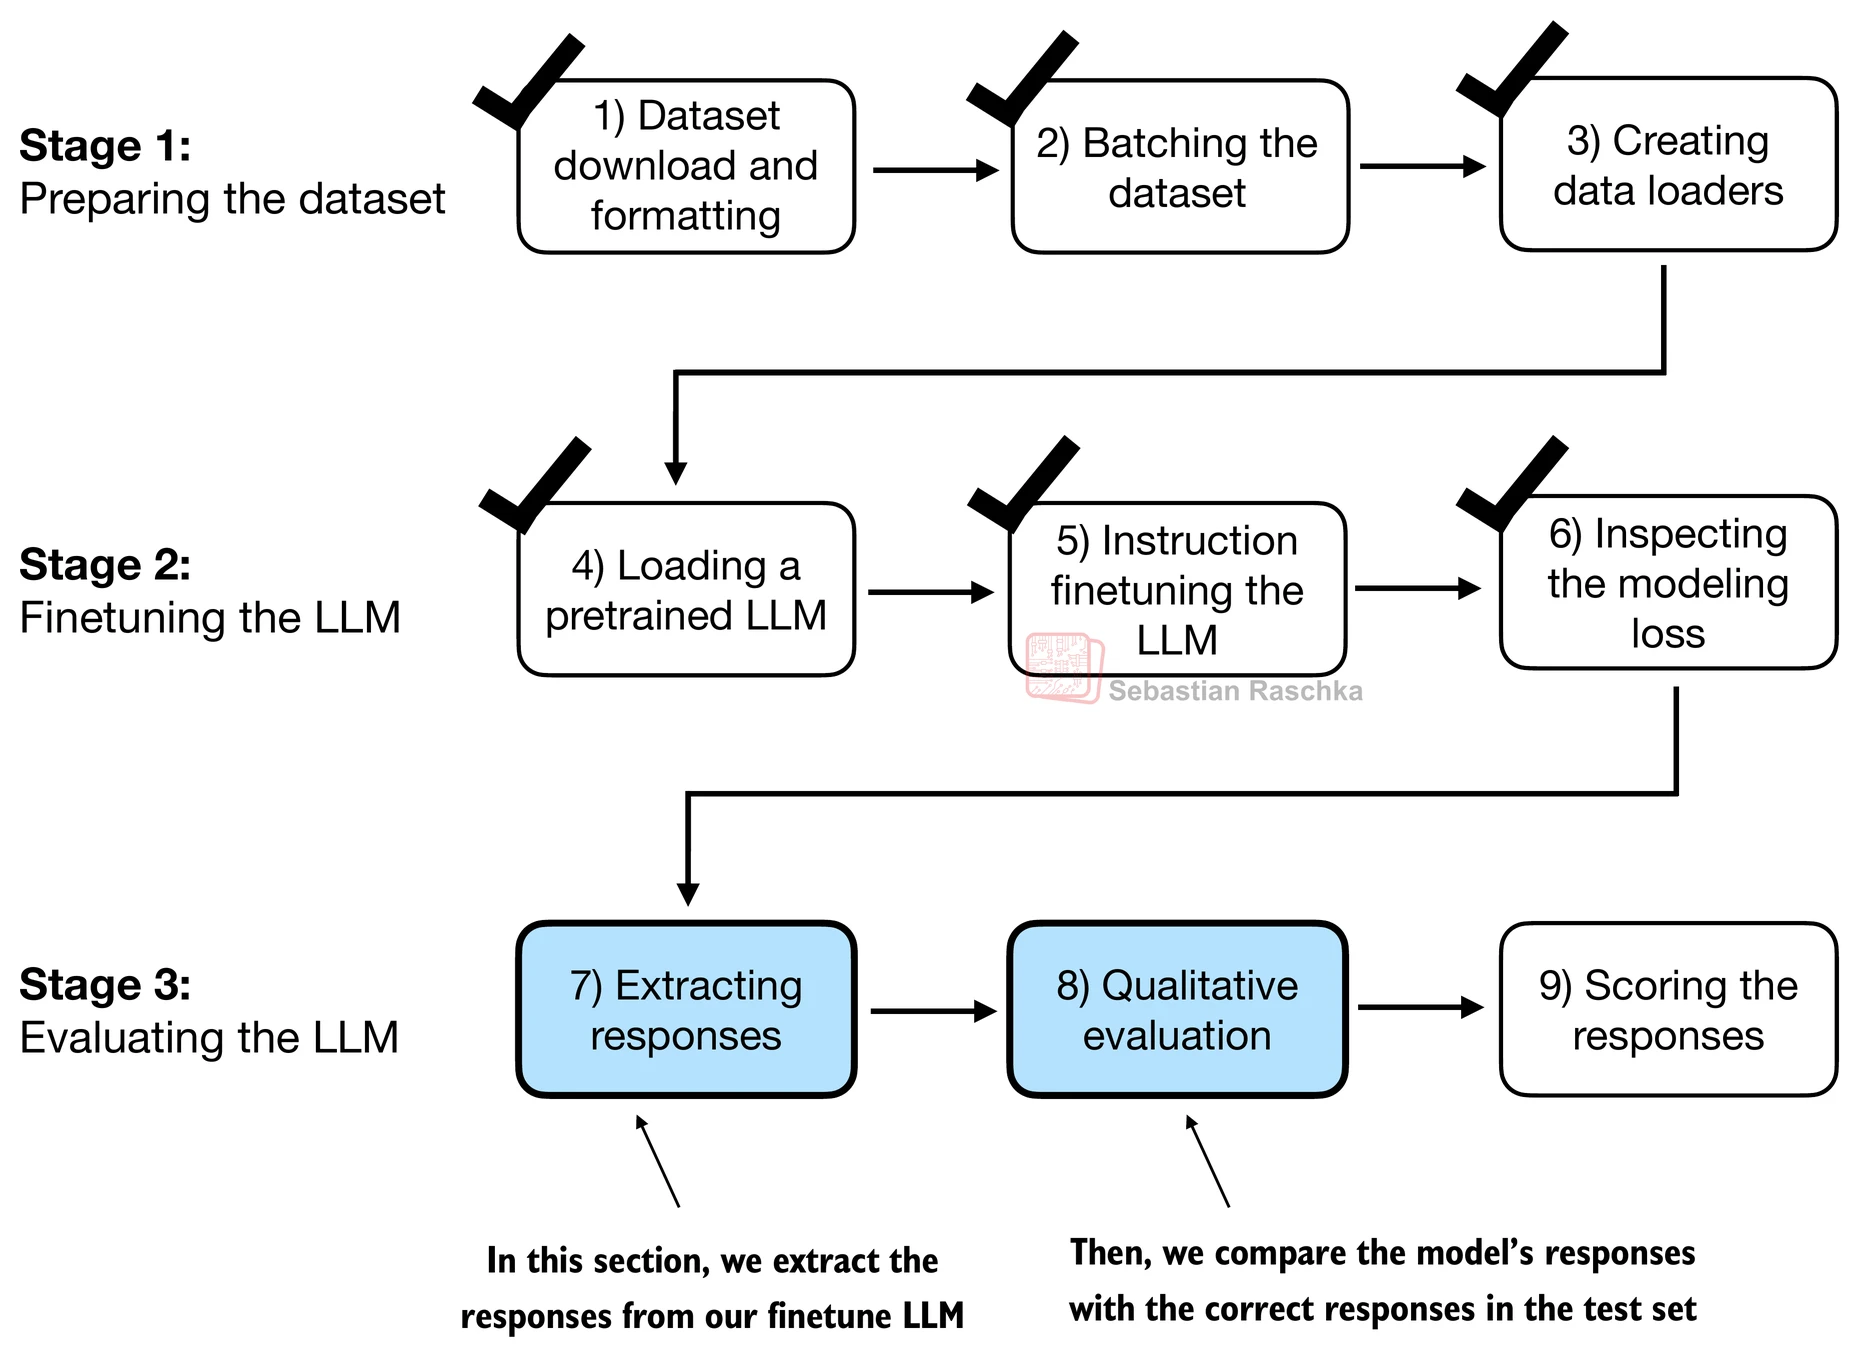
We need to run the test dataset for scoring

Save the model

In [ ]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Test model on a few entry in the test data 

In [20]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is typically associated with a persistent, unstable low pressure system that produces frequently intense thunderstorms and cold, windy conditions.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Pr

Evaluating a chatboy is more nuanced as unlike classification it isn't just right or wrong 

There are 3 main methods:
1. benchmarks to compare to other chatbots 
2. human preference 
3. automated benchmarks from another llm

Turn the test data into a combination with intructions and save as json

In [ ]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

 65%|██████▌   | 72/110 [21:11<10:49, 17.10s/it]

In [ ]:
print(test_data[0])